In [1]:
marks = [45, 60, 72, 38, 90]

total = 0

for i in range(len(marks) - 1):
    total += marks[i]

average = total / len(marks)

if average > 50:
    print("Class passed")
else:
    print("Class failed")

print("Average:", average)

Class failed
Average: 43.0


In [2]:
import pandas as pd


In [3]:
data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}

df = pd.DataFrame(data)

df


,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True
5,106,88,19,80,True


In [4]:
df.shape


(6, 5)

In [5]:
df.head()


,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          6 non-null      int64
 1   attendance_percent  6 non-null      int64
 2   assignment_score    6 non-null      int64
 3   quiz_score          6 non-null      int64
 4   lab_completed       6 non-null      bool 
dtypes: bool(1), int64(4)
memory usage: 330.0 bytes


In [7]:
df.describe()

,student_id,attendance_percent,assignment_score,quiz_score
count,6.000000,6.000000,6.000000,6.000000
mean,103.500000,74.500000,14.333333,58.333333
std,1.870829,17.073371,4.033196,18.007406
min,101.000000,45.000000,8.000000,30.000000
25%,102.250000,68.750000,12.500000,49.750000
50%,103.500000,77.500000,14.500000,60.000000
75%,104.750000,86.250000,17.250000,70.250000
max,106.000000,92.000000,19.000000,80.000000


In [8]:
df['total_score'] = df['assignment_score'] + df['quiz_score']
df


,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score
0,101,92,18,72,True,90
1,102,67,12,48,False,60
2,103,81,15,65,True,80
3,104,45,8,30,False,38
4,105,74,14,55,True,69
5,106,88,19,80,True,99


In [9]:
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [10]:
eligible_students = df[df["eligible"] == True]
eligible_students


,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

### Distribution of `attendance_percent` and `total_score`

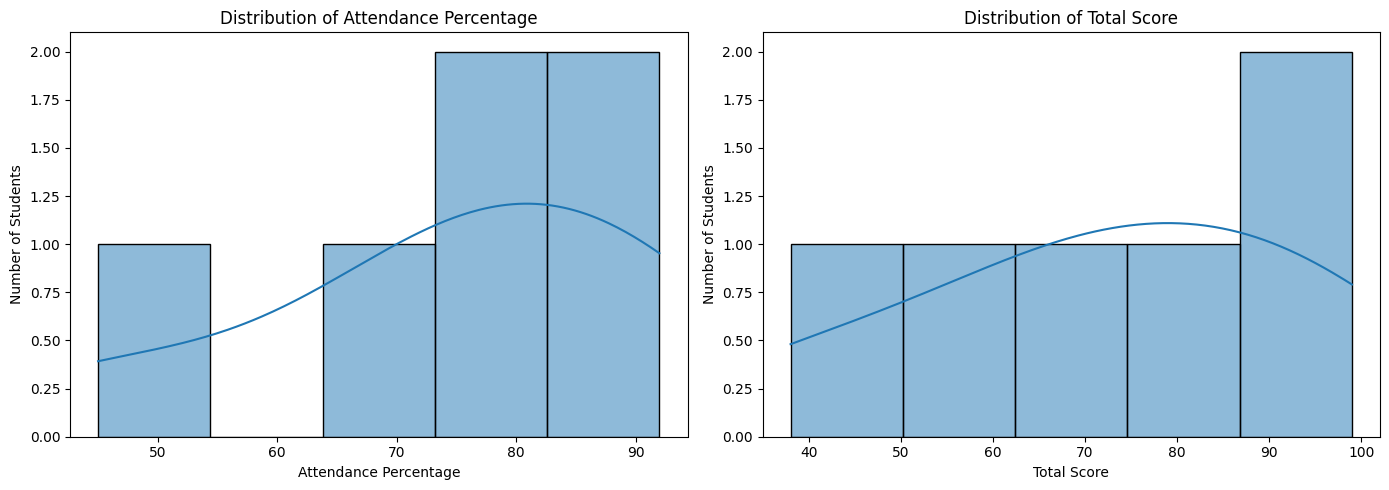

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['attendance_percent'], bins=5, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Attendance Percentage')
axes[0].set_xlabel('Attendance Percentage')
axes[0].set_ylabel('Number of Students')

sns.histplot(df['total_score'], bins=5, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Total Score')
axes[1].set_xlabel('Total Score')
axes[1].set_ylabel('Number of Students')

plt.tight_layout()
plt.show()

These histograms show the distribution of attendance percentage and total scores among the students. We can see how the scores and attendance are spread out. Now, let's look at the relationship between attendance percentage and total score.

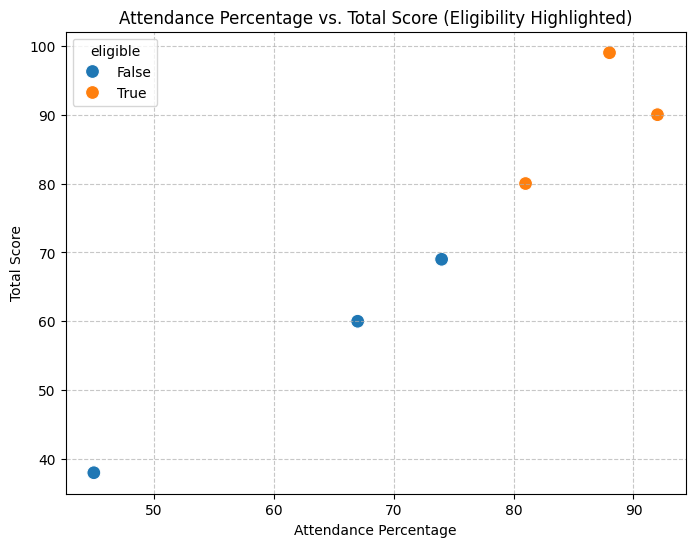

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='attendance_percent', y='total_score', hue='eligible', data=df, s=100)
plt.title('Attendance Percentage vs. Total Score (Eligibility Highlighted)')
plt.xlabel('Attendance Percentage')
plt.ylabel('Total Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This scatter plot helps visualize the relationship between attendance and total scores, with eligible students highlighted. It clearly shows the thresholds for eligibility. Finally, let's see the count of eligible versus non-eligible students.

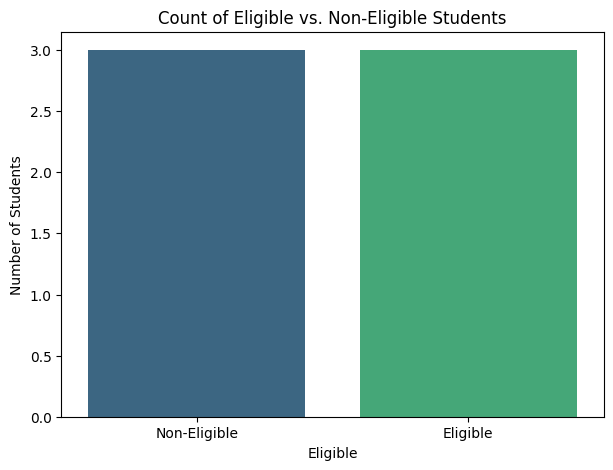

In [20]:
plt.figure(figsize=(7, 5))
sns.countplot(x='eligible', data=df, hue='eligible', legend=False, palette='viridis')
plt.title('Count of Eligible vs. Non-Eligible Students')
plt.xlabel('Eligible')
plt.ylabel('Number of Students')
plt.xticks([0, 1], ['Non-Eligible', 'Eligible'])
plt.show()

### Impact of Lab Completion on Total Score

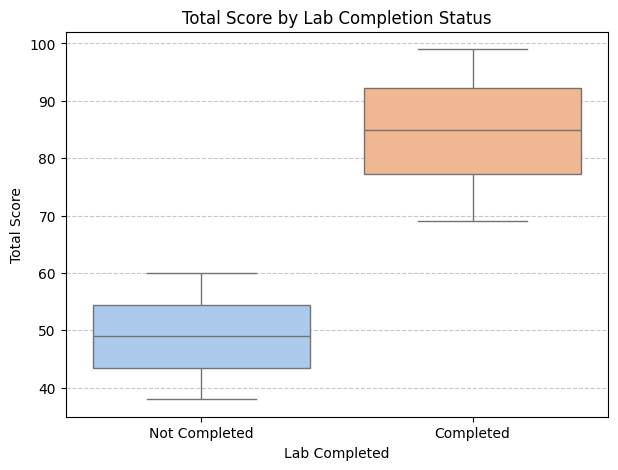

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}
df = pd.DataFrame(data)
df['total_score'] = df['assignment_score'] + df['quiz_score']
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)

plt.figure(figsize=(7, 5))
sns.boxplot(x='lab_completed', y='total_score', data=df, hue='lab_completed', legend=False, palette='pastel')
plt.title('Total Score by Lab Completion Status')
plt.xlabel('Lab Completed')
plt.ylabel('Total Score')
plt.xticks([0, 1], ['Not Completed', 'Completed'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This box plot illustrates how completing labs might influence the total scores of students. Now, let's look at the distribution of individual assignment and quiz scores.

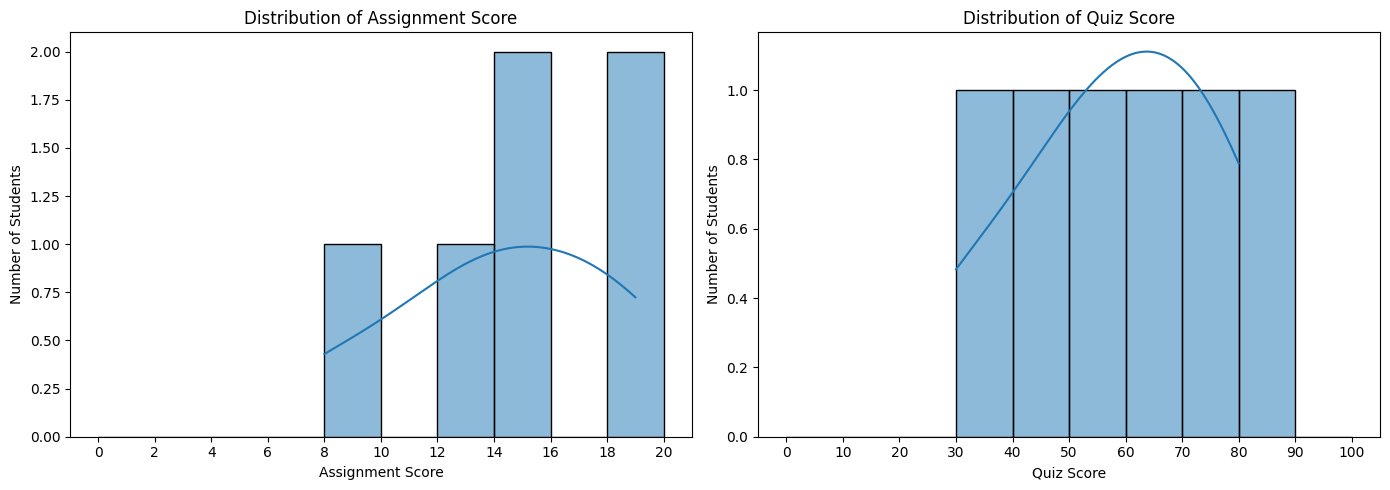

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['assignment_score'], bins=range(0, 21, 2), kde=True, ax=axes[0])
axes[0].set_title('Distribution of Assignment Score')
axes[0].set_xlabel('Assignment Score')
axes[0].set_ylabel('Number of Students')
axes[0].set_xticks(range(0, 21, 2))

sns.histplot(df['quiz_score'], bins=range(0, 101, 10), kde=True, ax=axes[1])
axes[1].set_title('Distribution of Quiz Score')
axes[1].set_xlabel('Quiz Score')
axes[1].set_ylabel('Number of Students')
axes[1].set_xticks(range(0, 101, 10))

plt.tight_layout()
plt.show()

These histograms show the individual distributions of assignment and quiz scores, providing a view of student performance in each component. Finally, let's see the proportion of students who completed their labs versus those who did not.

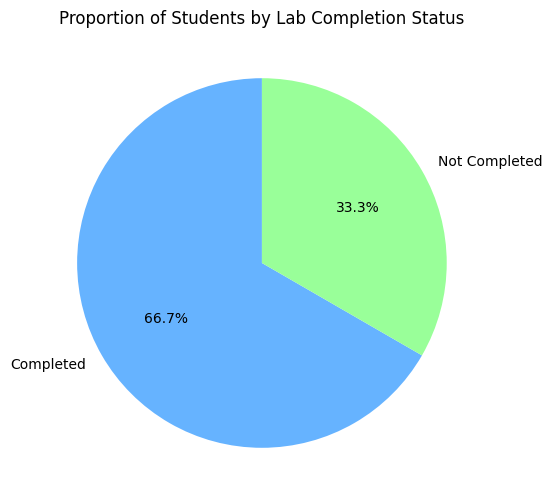

In [6]:
lab_completion_counts = df['lab_completed'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(lab_completion_counts, labels=['Completed', 'Not Completed'], autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99'])
plt.title('Proportion of Students by Lab Completion Status')
plt.show()

This box plot illustrates how completing labs might influence the total scores of students. Now, let's look at the distribution of individual assignment and quiz scores.

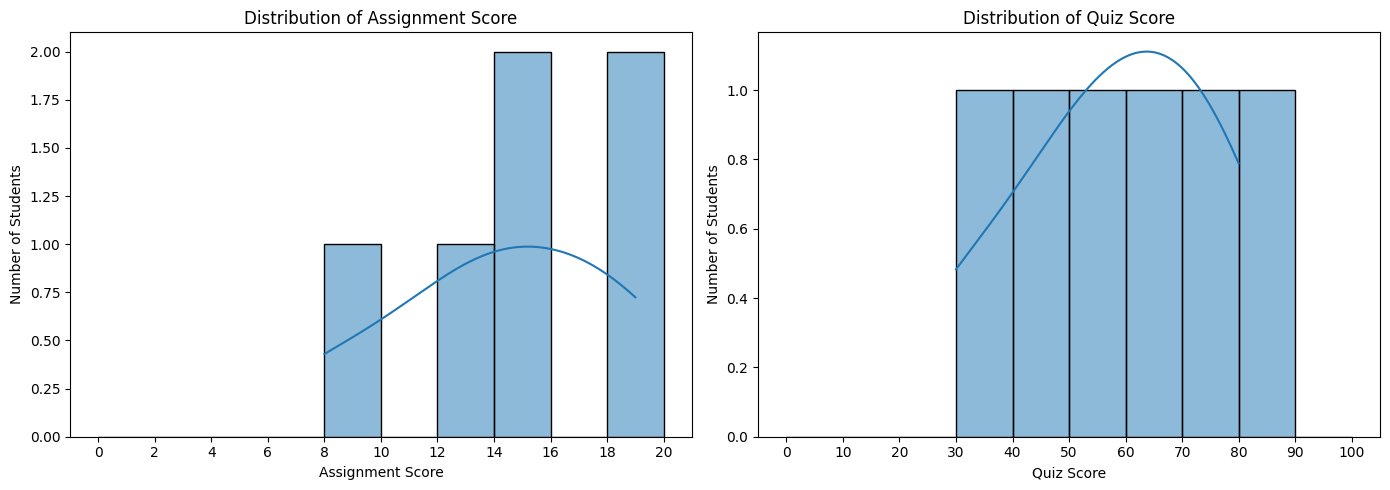

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['assignment_score'], bins=range(0, 21, 2), kde=True, ax=axes[0])
axes[0].set_title('Distribution of Assignment Score')
axes[0].set_xlabel('Assignment Score')
axes[0].set_ylabel('Number of Students')
axes[0].set_xticks(range(0, 21, 2))

sns.histplot(df['quiz_score'], bins=range(0, 101, 10), kde=True, ax=axes[1])
axes[1].set_title('Distribution of Quiz Score')
axes[1].set_xlabel('Quiz Score')
axes[1].set_ylabel('Number of Students')
axes[1].set_xticks(range(0, 101, 10))

plt.tight_layout()
plt.show()

These histograms show the individual distributions of assignment and quiz scores, providing a view of student performance in each component. Finally, let's see the proportion of students who completed their labs versus those who did not.

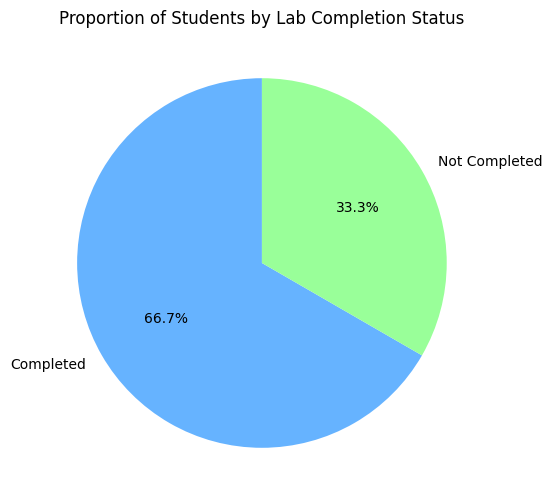

In [8]:
lab_completion_counts = df['lab_completed'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(lab_completion_counts, labels=['Completed', 'Not Completed'], autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99'])
plt.title('Proportion of Students by Lab Completion Status')
plt.show()